# Overview

I've studied speaker theory in depth, and have followed Web forums and other online content for years. I've begun to form the opinion that *the Thiele-Small parameters are the wrong way to explain how speakers work. Instead, we should start with the response curves*. Here are my reasons:

1. Your ears are the ultimate judge of course, but the SPL curve is very close in second place for illustrating how a bass speaker is likely to sound, at low frequencies and moderate signal levels.
2. The parameters are abstractions, and involve a level of math and physics that are forbidding to most people.
3. Where do you get the parameters anyway? They're found by measuring curves!
4. Nowadays the designers use the paramaters as inputs to their modeling software, which produce curves.
5. You can quickly look at a curve and decide if a design idea stands a chance of working as a bass speaker.

This notebook is the beginning of an attempt to illustrate bass speaker design ideas using curves rather than parameters.

# My ulterior motive

Where am I headed? I haven't gotten there yet. I want to create an alternative route for learning how speakers work, that *starts with the curves* rather than the parameters. Here, you're watching me thinking my way through this process. In the future, I hope this turns into a useful tutorial.

**Cautionary note**: This is a work in progress, and may still contain minor bugs. Do not use this program for designing anything that's going to cost money or possibly not work.

# First, a bit of theory work

Before proceeding, I want to make sure that whatever I'm doing at least doesn't contradict the parameter-based theory that I'm already familiar with. *Mother nature doesn't need two contradictory models of how speakers work, and neither should we.*

But I'm going to take the liberty of simplifying things. This notebook makes a lot of assumptions, even beyond the basic electromechanical theory:

1. I'm still talking about low frequencies and moderate signal levels.
2. I will ignore inductance, since it's mainly applicable to higher frequencies.
3. I will also ignore the overall magnitude of SPL. All curves are pinned down at 0 dB at higher frequencies. There are plenty of equations for overall SPL, or you can get it from the modeling software.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import speakerTheorySympy as sps
import response_curve as rc

First, look at the full equation for driver excursion

In [2]:
sps.x_driver

BL*C_ms*V/(I*BL**2*C_ms*omega - C_ms*M_ms*Z_e*omega**2 + I*C_ms*R_ms*Z_e*omega + Z_e)

I'm now going to put the Thiele-Small parameters (which I just got done chastizing) back into this equation. Bear with me, I haven't documented this derivation yet.

$x \propto \dfrac 1 {f_s(1 + \kappa \dfrac {V_{as}}{V_{box}}) + \dfrac {if\cdot f_s}{Q_{ts}} - f^2}$

where

$\kappa = \dfrac {f^2}{f^2 - f_{port}^2}$ for ported boxes, and

$\kappa = 1$ for sealed boxes.

What I've done here is to go full circle with the parameters. You can follow this thread in my speaker theory paper, leadnig to the above result:

1. Start with the T-S parameters, which don't obviously relate to cone motion.
2. Unpacked the Thiele-Small parameters, turning them into electromechanical parameters that a physicist understands.
3. Used the e-m parameters to write an equation of motion for the driver.
4. Solve the equation of motion.
5. Ignore inductance, which makes the equations readable.
6. Put the T-S parameters back in!

Also, getting a bit further ahead of myself, the SPL curve is proportional to:

$SPL = SPL_0 + 20 \log_{10} \dfrac {f^2 \kappa} {f_s^2(1 + \kappa \dfrac {V_{as}}{V_{box}}) + \dfrac {if\cdot f_s}{Q_{ts}} - f^2}$

Why is this interesting? SPL as shown here is *the complete equation for the familiar speaker response curve*. Everything about the *sound* of a speaker (at low frequencies and moderate signal levels) is contained in this equation. No magic. The equation is a bit thick, but not all that bad, as it's a function of six parameters:

0. The overall sensitivity $SPL_0$
1. The resonant frequency of the cone in the box, which is exactly $f_s(1 + \dfrac {V_{as}}{V_{box}})$ for sealed systems, and slightly lower for ported systems because $\kappa < 1$. We'll see more of $\kappa$ below.
2. The port tuning frequency $f_{port}$
3. A small factor hidden in $f_s(1 + \kappa \dfrac {V_{as}}{V_{box}})$ that I don't have a name for, but slightly modifies SPL below the port tuning frequency. It's the difference between a high-compliance driver in a small box, and a low-compliance driver in a big box, only for ported systems. But huge boxes are not practical. I discovered this factor in the process of writing this article.
4. A total Q factor. Notice that the individual (electrical and mechanical) Q factors don't appear here.
5. While not shown here, inductance is another factor, but has minimal effect around the frequencies where box design is important.

**Why bother with the rest of the parameters?** Two reasons:

1. The published parameters are *over-complete* meaning that they're not all independent of one another. For instance you don't need $Q_{ts}$ if you've got $Q_{es}$ and $Q_{ms}$. And the electromechanical parameters (such as $BL$ and $M_{ms}$) are just a rearrangement of the Thiele-Small parameters.
2. There are more curves, such as impedance, excursion, and port air speed, which are important for the design process, for instance to determine the overall power handling capability of a speaker.

"Speed" of speakers is not a reason. Bassists have been fascinated by "speed" of speakers for as long as I can remember, but time response functions, such as transient and step response, are governed by exactly the same equation as SPL, with the same parameters. I hope to get into this in greater depth, but for now, a decent rule of thumb is that transient response is governed by the ratio of the resonant frequency to the total Q factor. This is precisely true for sealed speakers, and approximately true for ported systems. Since Q doesn't change very much in bass speakers (at most by a factor of 2), that rule boils down to "higher speed means less bass response."

# Let's look at some curves

## One of my old designs

This is one of the speakers that I've built. My intention was to approximate the response of a small sealed cab in the GK MB150E combo, but with a modern driver and more power handling.

The graph for the GK combo is just a simulation of the GK speaker for the sake of illustration.

I built it about 20 years ago, and my modeling program was a lot more primitive at the time, but it worked. I used this speaker a lot for jazz gigs on both electric and upright bass. You can tell from the curve that there's not a lot of bass response there, but the GK combo didn't have a lot of bass response either.

But this is a useful starting point because it illustrates a lot of points. First, let's look at the SPL calculation:

    rc.spl_total(f, 53.1, 0.526, 81.1/32, 40)

What are these numbers?

* F_s = 53.1, the driver resonant frequency from the Eminence datasheet
* Q_ts = 0.526, the total Q factor from the datasheet
* H = 81.1 / 32, the ratio of the Q_ts factor from the datasheet, and the box volume in liters
* F_port, the port tuning frequency

I want to point out again that *there's nothing more to it*. This is a complete description of the bass response of this speaker, neglecting overall SPL.

There's a noticeable "hump" in the response curve at the resonant frequency, but it's only 2 dB. It's one of the effects of stuffing this driver into a very small box. A much higher "hump" would lead to "boomy" sound, and would be avoided, but this amount is probably inaudible.

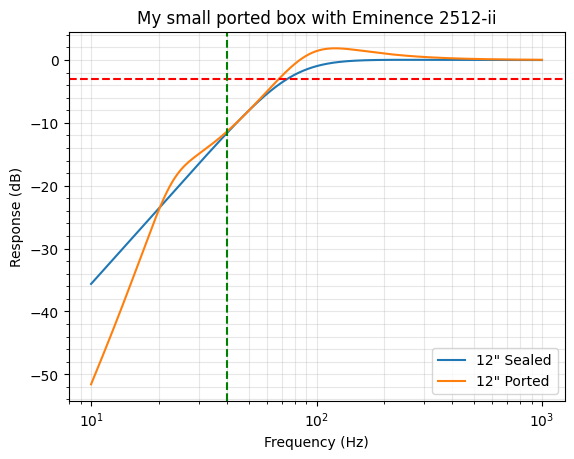

In [44]:
f = np.logspace(1, 3, 1000)
def decorate():
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Response (dB)')
    plt.gca().axhline(-3, color='red', linestyle='--')
    plt.gca().axvline(40, color='green', linestyle='--')
    plt.minorticks_on()
    plt.grid(which='both', alpha=0.3)
plt.semilogx(f, rc.spl_total(f, 55, 0.526, 1, None), label = '12" Sealed')
plt.semilogx(f, rc.spl_total(f, 53.1, 0.526, 67.44/32, 40), label = '12" Ported')
decorate()
plt.title('My small ported box with Eminence 2512-ii')
plt.legend()

## A bigger box for this driver?

You bet. Putting this driver in a much bigger box extends its low cutoff frequency down to about 35 Hz, and there's no in-between curve. But it's a huge box. Also, it will be limited in its power handling capability. But it shows that a single driver can produce two different kinds of sound quality depending on box and port design. *This would be quite an impressive woofer for a hi-fi system if you had space for it.*

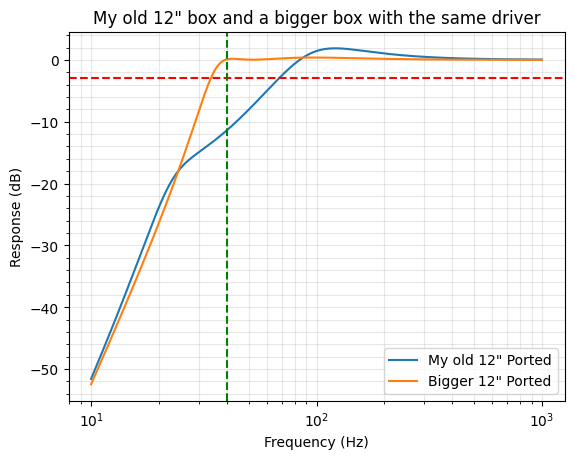

In [45]:
plt.semilogx(f, rc.spl_total(f, 53.1, 0.526, 67.44/32, 40), label = 'My old 12" Ported')
plt.semilogx(f, rc.spl_total(f, 53.1, 0.526, 67.44/120, 40), label = 'Bigger 12" Ported')
decorate()
plt.title('My old 12" box and a bigger box with the same driver')
plt.legend()

In [46]:
# Code for converting this document to HTML
if __name__ == '__main__':
    if input('Save this notebook before proceeding. OK? (y/n)') == 'y':
        !python3 -m jupyter nbconvert --to pdf ./"Playing with the curves.ipynb"

[NbConvertApp] Converting notebook ./Playing with the curves.ipynb to pdf
[NbConvertApp] Support files will be in Playing with the curves_files/
[NbConvertApp] Making directory ./Playing with the curves_files
[NbConvertApp] Writing 48182 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 245750 bytes to Playing with the curves.pdf
